In [12]:
from utils import *

import numpy as np
import pandas as pd
import scipy.signal as signal
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from collections import defaultdict

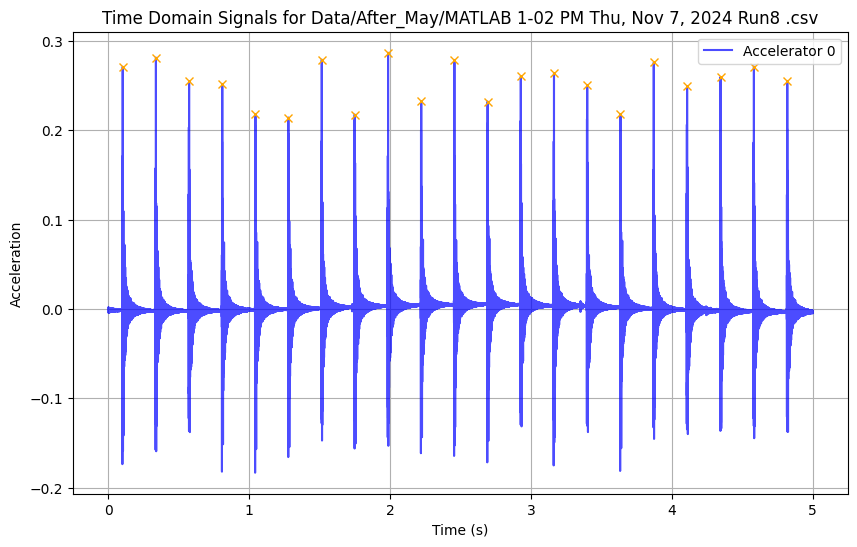

In [201]:
file = 'Data/After_May/MATLAB 1-02 PM Thu, Nov 7, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-00 PM Fri, Jun 28, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-51 PM Tue, Oct 29, 2024 Run13 .csv'
acceleration0 = get_file(file)
x, y = get_peaks(acceleration0)

plot_file(file)

In [202]:
diffs = []
for i in range(len(x)-1):
    for j in range(i+1, len(x)):
        diffs.append(float(x[j] - x[i]))
# diffs.sort()
# [round(x, 2) for x in diffs]

In [96]:
# Test
# diffs = [1, 1.00001, 1.00002, 1.00004, 1.99999, 2, 2.00001, 2.00002, 2.5, 2.50000001, 2.50001, 2.50002]

In [203]:
def summarize_clusters(diffs, random_state=0):
    """
    Performs GMM clustering on diffs and returns a list of clusters sorted by mean.

    Each cluster is represented as a dictionary with keys:
    - 'mean': mean of the cluster
    - 'sd': standard deviation of the cluster
    - 'n': number of points in the cluster
    """
    min_components = 1
    max_components = min(100, max(2, len(diffs) // 5))
    # max_components = len(diffs)

    X = np.array(diffs).reshape(-1, 1)
    bics, models = [], []

    # Fit models for different cluster counts
    for k in range(min_components, max_components + 1):
        model = GaussianMixture(n_components=k, random_state=random_state).fit(X)
        bics.append(model.bic(X))
        models.append(model)

    # Select best model
    best_index = np.argmin(bics)
    best_model = models[best_index]
    labels = best_model.predict(X)

    # Group values by cluster
    cluster_data = defaultdict(list)
    for val, label in zip(diffs, labels):
        cluster_data[label].append(val)

    # Create summary dictionaries
    clusters = []
    for values in cluster_data.values():
        values = np.array(values)
        if len(values) < 2:
            continue
        cluster_info = {
            'mean': np.mean(values),
            'sd': np.std(values),
            'n': len(values)
        }
        clusters.append(cluster_info)

    # Sort clusters by mean
    clusters.sort(key=lambda x: x['mean'])
    return clusters

clusters = summarize_clusters(diffs)
clusters

[{'mean': np.float64(0.23581000000000002),
  'sd': np.float64(0.0009449338601193526),
  'n': 20},
 {'mean': np.float64(0.47157368421052626),
  'sd': np.float64(0.001261512085706015),
  'n': 19},
 {'mean': np.float64(0.7072833333333333),
  'sd': np.float64(0.0018010028070803005),
  'n': 18},
 {'mean': np.float64(0.9429352941176471),
  'sd': np.float64(0.0021614105352130587),
  'n': 17},
 {'mean': np.float64(1.17854375),
  'sd': np.float64(0.002441559120213915),
  'n': 16},
 {'mean': np.float64(1.4142333333333332),
  'sd': np.float64(0.002559340192749292),
  'n': 15},
 {'mean': np.float64(1.6498142857142855),
  'sd': np.float64(0.002719468735632307),
  'n': 14},
 {'mean': np.float64(1.8855307692307695),
  'sd': np.float64(0.0026996822079031076),
  'n': 13},
 {'mean': np.float64(2.1211583333333333),
  'sd': np.float64(0.002828267530171472),
  'n': 12},
 {'mean': np.float64(2.356809090909091),
  'sd': np.float64(0.002944472339040029),
  'n': 11},
 {'mean': np.float64(2.5924899999999997),
 

In [204]:
from math import sqrt
from scipy.stats import norm

def prob_integer_multiple(base, sd_base, n_base, candidate, sd_candidate, n_candidate):
    """
    Computes the probability that the candidate mean is an integer multiple of the base mean,
    using propagated standard error.

    Parameters:
    - base, sd_base, n_base: mean, std, and sample size of base cluster
    - candidate, sd_candidate, n_candidate: same for candidate cluster

    Returns:
    - best_k: closest integer multiple
    - probability: two-tailed probability that ratio ≈ k
    """
    ratio = candidate / base
    best_k = round(ratio)

    # Use standard error (not just std dev)
    se_base = sd_base / sqrt(n_base)
    se_candidate = sd_candidate / sqrt(n_candidate)

    # Error propagation for ratio
    ratio_se = ratio * sqrt((se_candidate / candidate)**2 + (se_base / base)**2)

    z = abs(ratio - best_k) / ratio_se
    probability = 2 * (1 - norm.cdf(z))  # two-tailed

    return probability


In [205]:
def remove_integer_multiples(clusters, p_thresh=0.05):
    keep = [True] * len(clusters)

    for i in range(len(clusters) - 1):
        if not keep[i]:
            continue
        for j in range(i + 1, len(clusters)):
            if not keep[j]:
                continue

            ci = clusters[i]
            cj = clusters[j]

            p = prob_integer_multiple(
                base=ci["mean"], sd_base=ci["sd"], n_base=ci["n"],
                candidate=cj["mean"], sd_candidate=cj["sd"], n_candidate=cj["n"]
            )

            if p > p_thresh:
                # cluster_j is likely an integer multiple of cluster_i
                keep[j] = False

    # Return only the kept clusters
    pruned = [c for c, k in zip(clusters, keep) if k]
    return pruned

base_diffs = remove_integer_multiples(clusters)
base_diffs

[{'mean': np.float64(0.23581000000000002),
  'sd': np.float64(0.0009449338601193526),
  'n': 20}]

In [222]:
x

array([0.1035, 0.3391, 0.5746, 0.81  , 1.0454, 1.2791, 1.516 , 1.7496,
       1.9866, 2.222 , 2.4574, 2.693 , 2.9286, 3.1641, 3.3999, 3.6359,
       3.8722, 4.1088, 4.3458, 4.5828, 4.8197])

In [225]:
import numpy as np
from scipy.stats import norm

def count_hits_with_optimal_start(
    x, delta_t, sd, n, confidence=0.95, max_starts=10, extra_margin=0.00405
):
    import numpy as np
    from scipy.stats import norm

    x = np.array(x)
    se = sd / np.sqrt(n)
    z = norm.ppf(1 - (1 - confidence) / 2)
    margin = z * se + extra_margin

    best_hits = []
    best_tries = 0
    best_anchor = x[0]

    for i in range(min(max_starts, len(x))):
        anchor = x[i]
        hit_indices = []
        tries = 0
        k = 0

        while True:
            t = anchor + k * delta_t
            if t > x[-1]:
                break

            # Find all x values within the margin of the expected time t
            candidates = np.where((x >= t - margin) & (x <= t + margin))[0]
            if candidates.size > 0:
                hit_indices.append(candidates[0])  # take the first match

            tries += 1
            k += 1

        if len(hit_indices) > len(best_hits):
            best_hits = hit_indices
            best_tries = tries
            best_anchor = anchor

    # print("Hit indices:", best_hits)
    return delta_t, best_anchor, len(best_hits), best_tries



hit_lst = []
for i in range(len(base_diffs)):
    base_diff = base_diffs[i]
    delta_t, anchor, hits, tries = count_hits_with_optimal_start(x, base_diff["mean"], base_diff["sd"], base_diff["n"])
    hit_lst.append({"delta_t": float(round(delta_t, 4)), "anchor": float(anchor), "hits": hits, "tries": tries})

hit_lst

[{'delta_t': 0.2358, 'anchor': 0.5746, 'hits': 19, 'tries': 19}]